Hardware utilizado

In [17]:
import torch#

print("=" * 50)
print("INFORMACIÓN DE DISPOSITIVOS DISPONIBLES")
print("=" * 50)

# Verificar GPU NVIDIA
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"Número de GPUs NVIDIA: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print(f"GPU actual: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"cuDNN Version: {torch.backends.cudnn.version()}")

# Verificar Metal (Mac)
print(f"Metal disponible: {torch.backends.mps.is_available()}")

# CPU
print(f"CPU disponible: True (siempre)")

INFORMACIÓN DE DISPOSITIVOS DISPONIBLES
CUDA disponible: True
Número de GPUs NVIDIA: 1
GPU actual: NVIDIA GeForce MX110
CUDA Version: 12.8
cuDNN Version: 91002
Metal disponible: False
CPU disponible: True (siempre)


 Librerias y frameworks

In [18]:

#from torchvision import datasets
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from fastai.vision.all import *
import numpy as np 
import matplotlib.pyplot as plt


Clase Dataset 

!------------------
ImageNette 320
!------------------
Path: /home/dave/.fastai/data/imagenette2-320
Imágenes de entrenamiento: 9469
Imágenes de validación: 3925
Número de clases: 10
Clases: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
Mapeo de clases: {'n01440764': 0, 'n02102040': 1, 'n02979186': 2, 'n03000684': 3, 'n03028079': 4, 'n03394916': 5, 'n03417042': 6, 'n03425413': 7, 'n03445777': 8, 'n03888257': 9}
Formato de las imágenes: torch.Size([3, 224, 224])
Formato de las imágenes de validación: torch.Size([3, 224, 224])


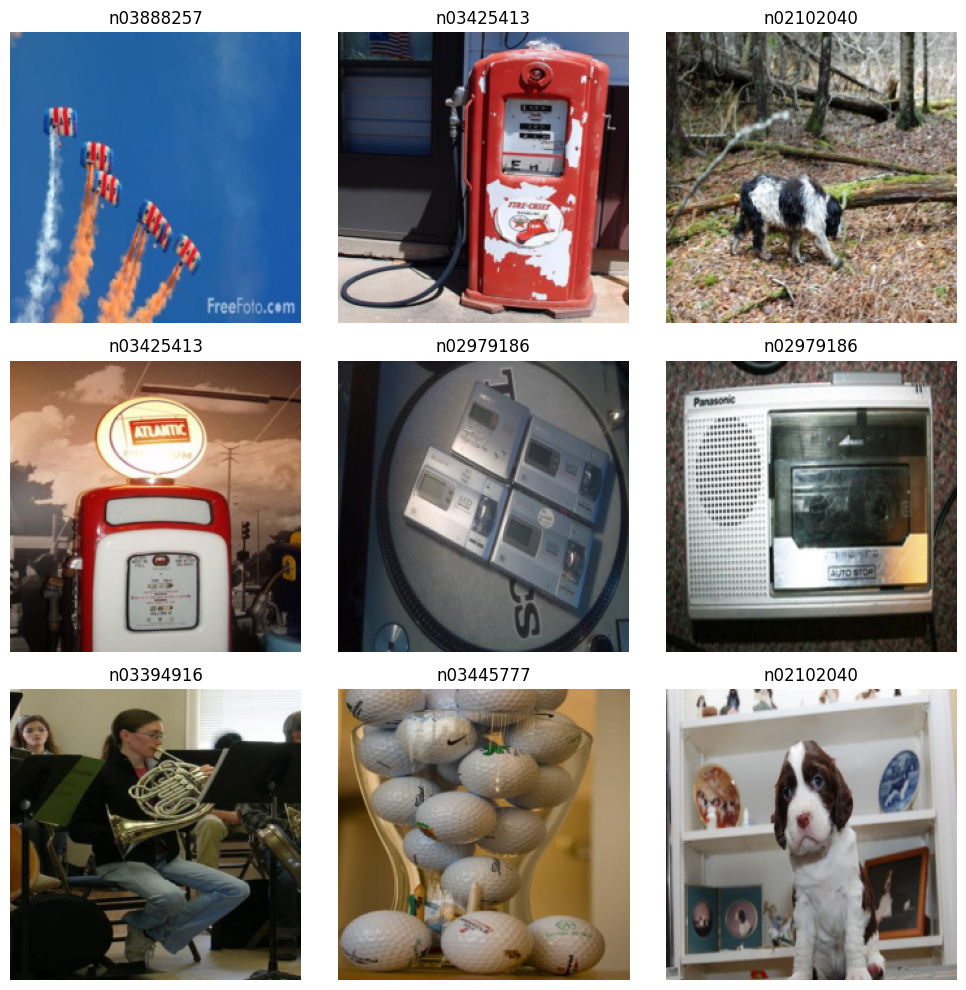

In [19]:
class DataSet():
    from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from fastai.vision.all import untar_data, URLs

class DataSet:
    def __init__(self, batch_size=32):
        self.root = Path(untar_data(URLs.IMAGENETTE_320))
        self.train_path = self.root / "train"
        self.val_path = self.root / "val"

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(), #Deja valores entre 0 y 1
        ])

        self.train_dataset = datasets.ImageFolder(self.train_path, transform=self.transform)
        self.val_dataset = datasets.ImageFolder(self.val_path, transform=self.transform)

        self.train_loader = DataLoader(self.train_dataset, batch_size=batch_size, shuffle=True)
        self.val_loader = DataLoader(self.val_dataset, batch_size=batch_size, shuffle=False)
    
    def print_data_set(self):
        print("!------------------")
        print("ImageNette 320")
        print("!------------------")
        print(f"Path: {self.root}")
        print(f"Imágenes de entrenamiento: {len(self.train_dataset)}")
        print(f"Imágenes de validación: {len(self.val_dataset)}")
        print(f"Número de clases: {len(self.train_dataset.classes)}")
        print(f"Clases: {self.train_dataset.classes}")
        print(f"Mapeo de clases: {self.train_dataset.class_to_idx}")
        print(f"Formato de las imágenes: {self.train_dataset[0][0].shape}")
        print(f"Formato de las imágenes de validación: {self.val_dataset[0][0].shape}")
    
    def visualize_samples(self):
        num_images = 9
        images, labels = next(iter(self.train_loader))
    
        fig, axes = plt.subplots(3, 3, figsize=(10, 10))
        for i, (img, label) in enumerate(zip(images[:num_images], labels[:num_images])):
            ax = axes[i // 3, i % 3]
            # Desnormalizar
            img = img.clamp(0, 1)  
            ax.imshow(img.permute(1, 2, 0))
            ax.set_title(self.train_dataset.classes[label])
            ax.axis('off')
        plt.tight_layout()
        plt.show()

dataset = DataSet()
dataset.print_data_set()
dataset.visualize_samples()
train_data_set = dataset.train_loader
val_data_set = dataset.val_loader
    


Preprocesamiento de la imagen

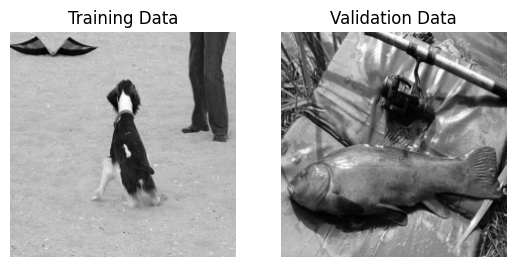

In [7]:
class PreProcessor:
    def __init__(self, train_loader, val_loader):
        train_images, _ = next(iter(train_loader))   # [B, C, H, W]
        val_images, _ = next(iter(val_loader))       # [B, C, H, W]

        self.gray_train = train_images[0].mean(dim=0)  # [H, W]
        self.gray_val = val_images[0].mean(dim=0)      # [H, W]

    def print_results(self):
        plt.subplot(1, 2, 1)
        plt.imshow(self.gray_train, cmap="gray")
        plt.title("Training Data")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(self.gray_val, cmap="gray")
        plt.title("Validation Data")
        plt.axis("off")
        plt.show()

pre_procesor = PreProcessor(train_data_set, val_data_set)
pre_procesor.print_results()
train_images = pre_procesor.gray_train
val_images = pre_procesor.gray_val
        

Red Neuronal

In [20]:
class NeuralNetwork():
    def __init__(self):
        self.input_size = 3 * 224 * 224
        self.hidden_size = 128 #valor arbitrario
        self.output_size = 10 #Número de clases en ImageNette
        self.EPOCHS = 10
        self.learning_rate = 0.05

    def get_input_size(self):
        return self.input_size
    
    def get_hidden_size(self):
        return self.hidden_size
    
    def get_output_size(self):
        return self.output_size
    
    def get_EPOCHS(self):
        return self.EPOCHS
    
    def get_learning_rate(self):
        return self.learning_rate
    
    def relu(self, z):
        return torch.clamp(z, min=0)

    def relu_derivative(self, z):
        return (z > 0).float()

    def softmax(self, z):
        return torch.softmax(z, dim=1)

    def mse_loss(self, y_pred, y_true_one_hot):
        return torch.mean((y_pred - y_true_one_hot) ** 2)

    def mse_derivative(self, y_pred, y_true_one_hot):
        n = y_pred.shape[0]
        return 2 * (y_pred - y_true_one_hot) / n
    
    def one_hot_encode(self, labels, num_classes):
        return torch.nn.functional.one_hot(labels.long(), num_classes=num_classes).float()

    def forward(self, X, weights):
        if X.dim() == 1:
            X = X.unsqueeze(0)
        X = X.float()

        w1, b1 = weights.get_W1(), weights.get_b1()
        w2, b2 = weights.get_W2(), weights.get_b2()

        # Capa 1: Entrada -> Oculta
        z1 = X @ w1 + b1
        a1 = self.relu(z1)

        # Capa 2: Oculta -> Salida
        z2 = a1 @ w2 + b2
        a2 = self.softmax(z2)

        cache = {
            'X': X,
            'z1': z1, 'a1': a1,
            'z2': z2, 'a2': a2
        }

        return a2, cache
    
    def backward(self, cache, y_true_one_hot, weights):
        X = cache['X']
        a1, z1 = cache['a1'], cache['z1']
        a2 = cache['a2']

        w2 = weights.get_W2()

        # Gradientes capa de salida
        dz2 = self.mse_derivative(a2, y_true_one_hot)
        dw2 = a1.T @ dz2
        db2 = torch.sum(dz2, dim=0, keepdim=True)

        # Gradientes capa oculta
        dz1 = (dz2 @ w2.T) * self.relu_derivative(z1)
        dw1 = X.T @ dz1
        db1 = torch.sum(dz1, dim=0, keepdim=True)

        gradient = {
            'dw1': dw1,
            'db1': db1,
            'dw2': dw2,
            'db2': db2
            }

        return gradient

    def train_batch(self, X_batch, y_batch, weights):
        if X_batch.dim() == 4:
            X_batch = X_batch.view(X_batch.size(0), -1)

        y_batch = y_batch.long()
        output, cache = self.forward(X_batch, weights)
        y_one_hot = self.one_hot_encode(y_batch, num_classes=weights.get_W2().shape[1])
        loss = self.mse_loss(output, y_one_hot)
        gradient = self.backward(cache, y_one_hot, weights)

        predictions = torch.argmax(output, dim=1)
        accuracy = (predictions == y_batch).float().mean()
        return loss.item(), accuracy.item(), gradient

    def predict_proba(self, X, weights):
        output, _ = self.forward(X, weights)
        return output

    def predict(self, X, weights):
        return torch.argmax(self.predict_proba(X, weights), dim=1)

neural_network = NeuralNetwork()
    


Inicializacion de pesos

In [21]:
class Weights():
    def __init__(self, input_size, hidden_size, output_size):
        self.W1 = torch.rand(input_size, hidden_size) * 0.01  # [input_size, hidden_size]
        self.b1 = torch.zeros((1, hidden_size))                       # [1, hidden_size]
        self.W2 = torch.rand(hidden_size, output_size) * 0.01 # [hidden_size, output_size]
        self.b2 = torch.zeros((1, output_size))                       # [1, output_size]
    
    def get_W1(self):
        return self.W1

    def get_W2(self):
        return self.W2
    
    def get_b1(self):
        return self.b1
    
    def get_b2(self):
        return self.b2

    def set_W1(self, new_W1):
        self.W1 = new_W1

    def set_W2(self, new_W2):
        self.W2 = new_W2

    def set_b1(self, new_b1):
        self.b1 = new_b1

    def set_b2(self, new_b2):
        self.b2 = new_b2

    def update_weigths(self, gradient, learning_rate):
        self.W1 -= learning_rate * gradient['dw1']
        self.b1 -= learning_rate * gradient['db1']
        self.W2 -= learning_rate * gradient['dw2']
        self.b2 -= learning_rate * gradient['db2']
    

    def print_weigths(self):
        print(f"W1 shape: {self.W1.shape}, b1 shape: {self.b1.shape}")
        print(f"W2 shape: {self.W2.shape}, b2 shape: {self.b2.shape}")   
        print(f"W1 sample: {self.W1[0, :5]}")  # Muestra los primeros 5 pesos de la primera neurona oculta
        print(f"W2 sample: {self.W2[0, :5]}")  # Muestra los primeros 5 pesos de la primera neurona de salida 

weights = Weights(neural_network.get_input_size(), neural_network.get_hidden_size(), neural_network.get_output_size())
weights.print_weigths()
        

W1 shape: torch.Size([150528, 128]), b1 shape: torch.Size([1, 128])
W2 shape: torch.Size([128, 10]), b2 shape: torch.Size([1, 10])
W1 sample: tensor([0.0055, 0.0064, 0.0016, 0.0037, 0.0087])
W2 sample: tensor([0.0029, 0.0030, 0.0021, 0.0099, 0.0066])


codigo main

In [27]:
import time 

def validate(neural_network, val_data_set, weights, epoch):
    with torch.no_grad():
        val_loss_sum = 0.0
        val_acc_sum = 0.0
        val_batches = 0

        for val_images, val_labels in val_data_set:
            if val_images.dim() == 4:
                val_images = val_images.view(val_images.size(0), -1)

            val_labels = val_labels.long()
            val_output, _ = neural_network.forward(val_images, weights)
            val_one_hot = neural_network.one_hot_encode(
                val_labels,
                num_classes=weights.get_W2().shape[1]
            )
            val_loss = neural_network.mse_loss(val_output, val_one_hot).item()

            val_predictions = torch.argmax(val_output, dim=1)
            val_acc = (val_predictions == val_labels).float().mean().item()

            val_loss_sum += val_loss
            val_acc_sum += val_acc
            val_batches += 1

        val_loss_epoch = val_loss_sum / val_batches
        val_acc_epoch = val_acc_sum / val_batches

        if (epoch + 1) % 1 == 0:
            print(
                f"Epoch {epoch + 1}: "
                f"train_loss={train_loss_epoch:.6f}, train_acc={train_acc_epoch:.4f}, "
                f"val_loss={val_loss_epoch:.6f}, val_acc={val_acc_epoch:.4f}"
            )

start_time = time.time()   
# Entrenamiento por epocas usando TODO el conjunto de entrenamiento
for epoch in range(neural_network.get_EPOCHS()):
    train_loss_sum = 0.0
    train_acc_sum = 0.0
    train_batches = 0

    for images, labels in train_data_set:
        loss, acc, gradient = neural_network.train_batch(images, labels, weights)
        weights.update_weigths(gradient, neural_network.get_learning_rate())

        train_loss_sum += loss
        train_acc_sum += acc
        train_batches += 1

    train_loss_epoch = train_loss_sum / train_batches
    train_acc_epoch = train_acc_sum / train_batches

    validate(neural_network, val_data_set, weights, epoch)
end_time = time.time()
print(f"Training time: {end_time - start_time:.2f} seconds")

Epoch 1: train_loss=0.090006, train_acc=0.1040, val_loss=0.090028, val_acc=0.1019
Epoch 2: train_loss=0.090005, train_acc=0.1017, val_loss=0.090037, val_acc=0.0907
Epoch 3: train_loss=0.090008, train_acc=0.0989, val_loss=0.090046, val_acc=0.0907
Epoch 4: train_loss=0.090009, train_acc=0.1001, val_loss=0.090025, val_acc=0.1019
Epoch 5: train_loss=0.090010, train_acc=0.1015, val_loss=0.090035, val_acc=0.0907
Epoch 6: train_loss=0.090010, train_acc=0.1010, val_loss=0.090026, val_acc=0.1004
Epoch 7: train_loss=0.090007, train_acc=0.1009, val_loss=0.090019, val_acc=0.0907
Epoch 8: train_loss=0.090009, train_acc=0.0983, val_loss=0.090035, val_acc=0.0907
Epoch 9: train_loss=0.090004, train_acc=0.1022, val_loss=0.090012, val_acc=0.1004
Epoch 10: train_loss=0.090009, train_acc=0.0974, val_loss=0.090028, val_acc=0.0907
Training time: 1096.43 seconds


2. Dividiendo el entrenamiento 

funcion para dividir el dataset

In [22]:
def split_dataset_balanced_3(image_folder_dataset, batch_size=32, seed=42):
    """
    Divide un ImageFolder en 3 particiones lo mas equilibradas posible (estratificado por clase).
    Devuelve: subsets, dataloaders
    """
    if not hasattr(image_folder_dataset, "targets"):
        raise ValueError("El dataset debe tener atributo 'targets' (ej: torchvision.datasets.ImageFolder)")

    targets = np.array(image_folder_dataset.targets)
    rng = np.random.default_rng(seed)

    # Indices para cada clase
    class_to_indices = {}
    for idx, cls in enumerate(targets):
        class_to_indices.setdefault(int(cls), []).append(idx)

    split_indices = [[], [], []]

    # Reparto estratificado y balanceado por clase
    for cls in sorted(class_to_indices.keys()):
        cls_indices = np.array(class_to_indices[cls])
        rng.shuffle(cls_indices)

        parts = np.array_split(cls_indices, 3)
        for i in range(3):
            split_indices[i].extend(parts[i].tolist())

    subsets = [Subset(image_folder_dataset, idxs) for idxs in split_indices]
    loaders = [
        DataLoader(subsets[0], batch_size=batch_size, shuffle=True),
        DataLoader(subsets[1], batch_size=batch_size, shuffle=True),
        DataLoader(subsets[2], batch_size=batch_size, shuffle=True),
    ]

    print("Tamano de particiones:", [len(s) for s in subsets])
    return subsets, loaders


# Ejemplo de uso con el dataset de entrenamiento actual
train_subsets, train_split_loaders = split_dataset_balanced_3(
    dataset.train_dataset,
    batch_size=32,
    seed=42,
)

train_part1_loader, train_part2_loader, train_part3_loader = train_split_loaders

Tamano de particiones: [3159, 3156, 3154]


Entrenamiento promediando gradientes cada epoca

In [ ]:
import time

start_time = time.time()

# Modelo 1 (weights) ya existe; creamos modelo 2 y 3 con misma arquitectura
weights_2 = Weights(neural_network.get_input_size(), neural_network.get_hidden_size(), neural_network.get_output_size())
weights_3 = Weights(neural_network.get_input_size(), neural_network.get_hidden_size(), neural_network.get_output_size())

# Inicializar modelos 2 y 3 con los mismos parametros iniciales del modelo 1
weights_2.set_W1(weights.get_W1().clone())
weights_2.set_W2(weights.get_W2().clone())
weights_2.set_b1(weights.get_b1().clone())
weights_2.set_b2(weights.get_b2().clone())

weights_3.set_W1(weights.get_W1().clone())
weights_3.set_W2(weights.get_W2().clone())
weights_3.set_b1(weights.get_b1().clone())
weights_3.set_b2(weights.get_b2().clone())

for epoch in range(neural_network.get_EPOCHS()):
    train_loss_sum = 0.0
    train_acc_sum = 0.0
    train_steps = 0

    it1 = iter(train_part1_loader)
    it2 = iter(train_part2_loader)
    it3 = iter(train_part3_loader)

    # Cada modelo entrena con su particion correspondiente
    while True:
        batches = []

        try:
            batches.append((1, next(it1)))
        except StopIteration:
            pass

        try:
            batches.append((2, next(it2)))
        except StopIteration:
            pass

        try:
            batches.append((3, next(it3)))
        except StopIteration:
            pass

        if len(batches) == 0:
            break

        step_losses = []
        step_accs = []

        for model_id, (images, labels) in batches:
            if model_id == 1:
                loss_i, acc_i, grad_i = neural_network.train_batch(images, labels, weights)
                weights.update_weigths(grad_i, neural_network.get_learning_rate())
            elif model_id == 2:
                loss_i, acc_i, grad_i = neural_network.train_batch(images, labels, weights_2)
                weights_2.update_weigths(grad_i, neural_network.get_learning_rate())
            else:
                loss_i, acc_i, grad_i = neural_network.train_batch(images, labels, weights_3)
                weights_3.update_weigths(grad_i, neural_network.get_learning_rate())

            step_losses.append(loss_i)
            step_accs.append(acc_i)

        train_loss_sum += sum(step_losses) / len(step_losses)
        train_acc_sum += sum(step_accs) / len(step_accs)
        train_steps += 1

    # Promedio de parametros al final de la epoca
    avg_W1 = (weights.get_W1() + weights_2.get_W1() + weights_3.get_W1()) / 3
    avg_W2 = (weights.get_W2() + weights_2.get_W2() + weights_3.get_W2()) / 3
    avg_b1 = (weights.get_b1() + weights_2.get_b1() + weights_3.get_b1()) / 3
    avg_b2 = (weights.get_b2() + weights_2.get_b2() + weights_3.get_b2()) / 3

    weights.set_W1(avg_W1.clone())
    weights.set_W2(avg_W2.clone())
    weights.set_b1(avg_b1.clone())
    weights.set_b2(avg_b2.clone())

    # Sincronizar para que la siguiente epoca inicie igual en los 3 modelos
    weights_2.set_W1(avg_W1.clone())
    weights_2.set_W2(avg_W2.clone())
    weights_2.set_b1(avg_b1.clone())
    weights_2.set_b2(avg_b2.clone())

    weights_3.set_W1(avg_W1.clone())
    weights_3.set_W2(avg_W2.clone())
    weights_3.set_b1(avg_b1.clone())
    weights_3.set_b2(avg_b2.clone())

    train_loss_epoch = train_loss_sum / train_steps
    train_acc_epoch = train_acc_sum / train_steps

    validate(neural_network, val_data_set, weights, epoch)

end_time = time.time()
print(f"Training time: {end_time - start_time:.2f} seconds")

Epoch 1: train_loss=0.091773, train_acc=0.0969, val_loss=0.090018, val_acc=0.0907
Epoch 2: train_loss=0.090011, train_acc=0.0972, val_loss=0.090022, val_acc=0.0907
Epoch 3: train_loss=0.090011, train_acc=0.0966, val_loss=0.090025, val_acc=0.0907
Epoch 4: train_loss=0.090011, train_acc=0.1012, val_loss=0.090020, val_acc=0.0907
Epoch 5: train_loss=0.090011, train_acc=0.1012, val_loss=0.090024, val_acc=0.0907
Epoch 6: train_loss=0.090011, train_acc=0.1007, val_loss=0.090022, val_acc=0.0907
Epoch 7: train_loss=0.090011, train_acc=0.0987, val_loss=0.090019, val_acc=0.0907
Epoch 8: train_loss=0.090011, train_acc=0.1020, val_loss=0.090017, val_acc=0.0907
Epoch 9: train_loss=0.090011, train_acc=0.0970, val_loss=0.090024, val_acc=0.0907
Epoch 10: train_loss=0.090012, train_acc=0.1010, val_loss=0.090021, val_acc=0.0907
Training time: 1139.70 seconds


3. Utilizando workers

In [ ]:
from multiprocessing import Process, Pool

def train(train_data,data_labels,params):

        loss, accuracy, gradient = neural_network.train_batch(train_data, data_labels, params)
    
        return loss, accuracy, gradient

start_time = time.time()

# Modelo 1 (weights) ya existe; creamos modelo 2 y 3 con misma arquitectura
weights_2 = Weights(neural_network.get_input_size(), neural_network.get_hidden_size(), neural_network.get_output_size())
weights_3 = Weights(neural_network.get_input_size(), neural_network.get_hidden_size(), neural_network.get_output_size())

# Inicializar modelos 2 y 3 con los mismos parametros iniciales del modelo 1
weights_2.set_W1(weights.get_W1().clone())
weights_2.set_W2(weights.get_W2().clone())
weights_2.set_b1(weights.get_b1().clone())
weights_2.set_b2(weights.get_b2().clone())

weights_3.set_W1(weights.get_W1().clone())
weights_3.set_W2(weights.get_W2().clone())
weights_3.set_b1(weights.get_b1().clone())
weights_3.set_b2(weights.get_b2().clone())

with Pool(processes=4) as pool:

    for epoch in range(neural_network.get_EPOCHS()):
        train_loss_sum = 0.0
        train_acc_sum = 0.0
        train_steps = 0

        it1 = iter(train_part1_loader)
        it2 = iter(train_part2_loader)
        it3 = iter(train_part3_loader)

        # Cada modelo entrena con su particion correspondiente
        while True:
            batches = []

            try:
                batches.append((1, next(it1)))
            except StopIteration:
                pass

            try:
                batches.append((2, next(it2)))
            except StopIteration:
                pass

            try:
                batches.append((3, next(it3)))
            except StopIteration:
                pass

            if len(batches) == 0:
                break

            step_losses = []
            step_accs = []

            train_images_1, train_labels_1, train_images_2, train_labels_2, train_images_3, train_labels_3 = []

            for model_id, (images, labels) in batches:
                if model_id == 1:
                    train_images_1.append(images)   
                    train_labels_1.append(labels)
                elif model_id == 2:
                    train_images_2.append(images)
                    train_labels_2.append(labels)
                else:
                    train_images_3.append(images)
                    train_labels_3.append(labels)

            work_splits = [
                        (train_images_1, train_labels_1, weights),
                        (train_images_2, train_labels_2, weights),
                        (train_images_3, train_labels_3, weights),
                    ]
                
            losses, accuracys, gradients = pool.starmap(train, work_splits)

            accumulated_w1=0
            accumulated_b1=0
            accumulated_w2=0
            accumulated_b2=0
            for gradient in gradients:
                accumulated_w1 += gradient["dw1"]
                accumulated_b1 += gradient["db1"]
                accumulated_w2 += gradient["dw2"]
                accumulated_b2 += gradient["db2"]
            
            accumulated_w1 /= len(gradients)
            accumulated_b1 /= len(gradients)
            accumulated_w2 /= len(gradients)
            accumulated_b2 /= len(gradients)

            mean_gradient = {
                "dw1": accumulated_w1,
                "db1": accumulated_b1,
                "dw2": accumulated_w2,
                "db2": accumulated_b2,
            }

            w

            """train_loss_sum += sum(step_losses) / len(step_losses)
            train_acc_sum += sum(step_accs) / len(step_accs)
            train_steps += 1"""

        # Promedio de parametros al final de la epoca
        avg_W1 = (weights.get_W1() + weights_2.get_W1() + weights_3.get_W1()) / 3
        avg_W2 = (weights.get_W2() + weights_2.get_W2() + weights_3.get_W2()) / 3
        avg_b1 = (weights.get_b1() + weights_2.get_b1() + weights_3.get_b1()) / 3
        avg_b2 = (weights.get_b2() + weights_2.get_b2() + weights_3.get_b2()) / 3

        weights.set_W1(avg_W1.clone())
        weights.set_W2(avg_W2.clone())
        weights.set_b1(avg_b1.clone())
        weights.set_b2(avg_b2.clone())

        # Sincronizar para que la siguiente epoca inicie igual en los 3 modelos
        weights_2.set_W1(avg_W1.clone())
        weights_2.set_W2(avg_W2.clone())
        weights_2.set_b1(avg_b1.clone())
        weights_2.set_b2(avg_b2.clone())

        weights_3.set_W1(avg_W1.clone())
        weights_3.set_W2(avg_W2.clone())
        weights_3.set_b1(avg_b1.clone())
        weights_3.set_b2(avg_b2.clone())

        train_loss_epoch = train_loss_sum / train_steps
        train_acc_epoch = train_acc_sum / train_steps

        validate(neural_network, val_data_set, weights, epoch)

end_time = time.time()
print(f"Training time: {end_time - start_time:.2f} seconds")